In [1]:
"""
Source Heating Power Survey
============================
Produces:
  - Figure A.1: Ion count rate vs. source heating power (Appendix A.1)

Broad initial survey of the ion source's usable heating range, conducted at
2000 V detector bias / -7 mV threshold (30/06/26). Conducted at a lower
detector bias and over a wider heating power range than the matched-condition
efficiency scans in Chapter 4, so results here are not directly comparable
to those figures — this is a standalone characterization of source behavior.
"""

import pandas as pd
import numpy as np
import os
import glob
import shutil
import matplotlib.pyplot as plt

In [2]:
def read_mpa_file(filepath):
    """Reads an MPA file and returns (realtime, totalsum) from its ASCII header."""
    realtime = None
    totalsum = None

    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith("REALTIME") and realtime is None:
                realtime = float(line.split()[1].strip())
            elif line.startswith("TOTALSUM") and totalsum is None:
                totalsum = float(line.split()[1].strip())

    return realtime, totalsum


# Naming scheme: Current{amps}_{run}.mpa
# A "." is inserted after the first digit of {amps} to recover the correct
# float value (e.g. "075" -> "0.75").
def get_amps(filename):
    name_only = filename.replace("Current", "").replace(".mpa", "")
    if "_" in name_only:
        amps_str = name_only.split("_")[0]
    else:
        amps_str = name_only
    return float(amps_str[0] + "." + amps_str[1:])


def get_run(filename):
    """Extracts the run number from a Current*.mpa filename (defaults to 1 if unlabeled)."""
    name_only = filename.replace("Current", "").replace(".mpa", "")
    if "_" in name_only:
        return int(name_only.split("_")[1])
    return 1


def export_figure_csv(dataframe, filepath, description_lines):
    """Writes a CSV with a commented header block describing the table's
    purpose and thesis figure reference, followed by the actual data."""
    with open(filepath, "w") as f:
        for line in description_lines:
            f.write(f"# {line}\n")
    dataframe.to_csv(filepath, mode="a", index=False)


def archive_raw_files(filenames, source_folder, dest_subfolder):
    """Copies the raw .mpa files underlying a given figure/table into their
    own subfolder under thesis/raw/, preserving full provenance."""
    dest_path = os.path.join("thesis", "raw", dest_subfolder)
    os.makedirs(dest_path, exist_ok=True)

    copied, missing = [], []
    for fname in filenames:
        src = os.path.join(source_folder, fname)
        dst = os.path.join(dest_path, fname)
        if os.path.exists(src):
            shutil.copy2(src, dst)
            copied.append(fname)
        else:
            missing.append(fname)

    print(f"Copied {len(copied)} files to {dest_path}")
    if missing:
        print(f"WARNING: {len(missing)} files not found: {missing}")
    return copied, missing


def power_calc(V, I):
    """Heating power (W) = heater voltage (V) x heater current (A)."""
    return V * I

In [3]:
data_folder = "CurrentControl"
rows = []

for filepath in glob.glob(os.path.join(data_folder, "Current*.mpa")):
    filename = os.path.basename(filepath)

    amps = get_amps(filename)
    run = get_run(filename)
    realtime, totalsum = read_mpa_file(filepath)
    rate = totalsum / realtime

    rows.append({
        "current_amps": amps,
        "run": run,
        "file": filename,
        "realtime_s": realtime,
        "totalsum": totalsum,
        "rate_hz": rate
    })

current_pd = pd.DataFrame(rows).sort_values(by=["current_amps"]).reset_index(drop=True)
current_pd

,current_amps,run,file,realtime_s,totalsum,rate_hz
0,0.75,1,Current075.mpa,150.137,6.0,0.039964
1,0.80,1,Current080.mpa,150.122,15.0,0.099919
2,0.85,1,Current085.mpa,150.052,170.0,1.132941
3,0.90,1,Current090.mpa,150.124,2049.0,13.648717
4,0.95,1,Current095.mpa,150.055,14540.0,96.897804
5,1.00,1,Current100.mpa,150.016,105755.0,704.958138
6,1.05,1,Current105.mpa,150.106,462930.0,3084.020625
7,1.10,1,Current110.mpa,150.072,1256640.0,8373.580681


In [4]:
# Heater supply voltage (V) corresponding to each current setting.
# Test taken at 2000 V detector bias, -7 mV threshold - 30/06/26.
# Points targeted ~ [0.75, 0.8, 0.85, ..., 1.5] A in 0.05 A steps.
Voltage = [1.19, 1.35, 1.48, 1.63, 1.77, 1.92, 2.08, 2.25]  # V, one entry per current_amps row, in ascending order

assert len(Voltage) == len(current_pd), (
    f"Voltage list has {len(Voltage)} entries but current_pd has {len(current_pd)} rows — "
    "check that a run wasn't added/removed since this list was recorded."
)

current_pd['Voltage_V'] = Voltage
current_pd['Power'] = power_calc(current_pd['Voltage_V'], current_pd['current_amps'])
current_pd

,current_amps,run,file,realtime_s,totalsum,rate_hz,Voltage_V,Power
0,0.75,1,Current075.mpa,150.137,6.0,0.039964,1.19,0.8925
1,0.80,1,Current080.mpa,150.122,15.0,0.099919,1.35,1.0800
2,0.85,1,Current085.mpa,150.052,170.0,1.132941,1.48,1.2580
3,0.90,1,Current090.mpa,150.124,2049.0,13.648717,1.63,1.4670
4,0.95,1,Current095.mpa,150.055,14540.0,96.897804,1.77,1.6815
5,1.00,1,Current100.mpa,150.016,105755.0,704.958138,1.92,1.9200
6,1.05,1,Current105.mpa,150.106,462930.0,3084.020625,2.08,2.1840
7,1.10,1,Current110.mpa,150.072,1256640.0,8373.580681,2.25,2.4750


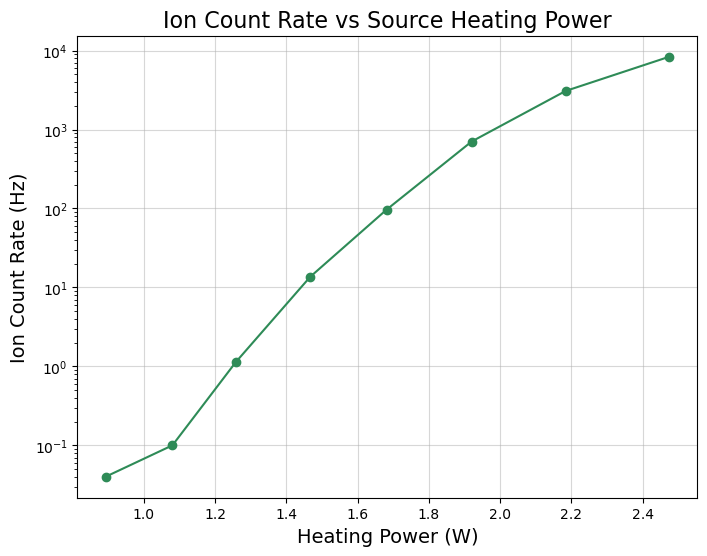

In [5]:
"""
Figure A.1: Ion Count Rate vs. Source Heating Power
------------------------------------------------------
"""

plt.figure(figsize=(8, 6))
plt.plot(current_pd["Power"], current_pd["rate_hz"], marker='o', linestyle='-', color='seagreen')
plt.yscale('log')
plt.xlabel('Heating Power (W)', fontsize=14)
plt.ylabel('Ion Count Rate (Hz)', fontsize=14)
plt.title('Ion Count Rate vs Source Heating Power', fontsize=16)
plt.grid(alpha=0.5)
plt.show()

In [6]:
description = [
    "Ion Count Rate vs. Source Heating Power",
    "Corresponds to Figure A.1",
    "",
    "Purpose: a broad initial survey of the ion source's usable heating range,",
    "before the narrower, matched-condition scans used for the transmission",
    "efficiency measurement (Chapter 4). Conducted at a lower detector bias",
    "and over a wider heating power range than the efficiency measurements,",
    "so values here are not directly comparable to those in Chapter 4.",
    "",
    "Test conducted at 2000V detector bias, -7mV threshold (30/06/26).",
    "Heating power computed as heater voltage x heater current.",
    "",
    "Columns:",
    "  current_amps - Source heater current (A)",
    "  voltage_v    - Source heater voltage (V)",
    "  power_w      - Heating power (W) = current_amps x voltage_v",
    "  file         - Source .mpa filename",
    "  realtime_s   - Acquisition real time (s)",
    "  totalsum     - Total detector counts",
    "  rate_hz      - Ion count rate (Hz) = totalsum / realtime_s",
]

export_cols_map = {
    "current_amps": "current_amps",
    "Voltage_V": "voltage_v",
    "Power": "power_w",
    "file": "file",
    "realtime_s": "realtime_s",
    "totalsum": "totalsum",
    "rate_hz": "rate_hz",
}

export_df = current_pd[list(export_cols_map.keys())].rename(columns=export_cols_map)
export_df = export_df.sort_values("current_amps").reset_index(drop=True)

export_figure_csv(export_df, "thesis/rate_vs_heating_power.csv", description)
print(export_df)

   current_amps  voltage_v  power_w            file  realtime_s   totalsum  \
0          0.75       1.19   0.8925  Current075.mpa     150.137        6.0   
1          0.80       1.35   1.0800  Current080.mpa     150.122       15.0   
2          0.85       1.48   1.2580  Current085.mpa     150.052      170.0   
3          0.90       1.63   1.4670  Current090.mpa     150.124     2049.0   
4          0.95       1.77   1.6815  Current095.mpa     150.055    14540.0   
5          1.00       1.92   1.9200  Current100.mpa     150.016   105755.0   
6          1.05       2.08   2.1840  Current105.mpa     150.106   462930.0   
7          1.10       2.25   2.4750  Current110.mpa     150.072  1256640.0   

       rate_hz  
0     0.039964  
1     0.099919  
2     1.132941  
3    13.648717  
4    96.897804  
5   704.958138  
6  3084.020625  
7  8373.580681  


In [7]:
# Figure A.1 — Ion Count Rate vs Source Heating Power
archive_raw_files(current_pd["file"].tolist(), "CurrentControl", "rate_vs_heating_power")

Copied 8 files to thesis/raw/rate_vs_heating_power


(['Current075.mpa',
  'Current080.mpa',
  'Current085.mpa',
  'Current090.mpa',
  'Current095.mpa',
  'Current100.mpa',
  'Current105.mpa',
  'Current110.mpa'],
 [])